In [7]:
import numpy as np
from world import World

def simulation(number_simulations, alpha, c):
    # number_simulations = 10000
    time_horizon = 3
    observations = np.zeros((number_simulations, time_horizon))

    for k in range(number_simulations):
        world = World(agent_type='bfe', c=c, alpha=alpha)
        world.run()
        observation = world.get_observations()
        observations[k] = observation

    number_rewards = np.sum(observations[:, 1] == 10) + np.sum(observations[:, 1] == 14) + np.sum(observations[:, 2] == 10) + np.sum(observations[:, 2] == 14)
    number_cues = np.sum(observations[:, 1] == 4) + np.sum(observations[:, 1] == 5)

    n_cue_and_reward = 0
    n_cue_and_no_reward = 0
    n_no_cue_and_reward = 0
    n_no_cue_and_no_reward = 0

    for obs in observations:
        if (obs[1] == 4 or obs[1] == 5) and (obs[2] == 10 or obs[2] == 14):
            n_cue_and_reward += 1
        if (obs[1] == 4 or obs[1] == 5) and not (obs[2] == 10 or obs[2] == 14):
            n_cue_and_no_reward += 1
        if not (obs[1] == 4 or obs[1] == 5) and (obs[2] == 10 or obs[2] == 14):
            n_no_cue_and_reward += 1
        if not (obs[1] == 4 or obs[1] == 5) and not (obs[2] == 10 or obs[2] == 14):
            n_no_cue_and_no_reward += 1

    return number_rewards, number_cues, n_cue_and_reward, n_cue_and_no_reward, n_no_cue_and_reward, n_no_cue_and_no_reward

    # print('Success ratio: ', number_rewards / number_simulations)
    # print('Cue (t=1) Ratio : ', number_cues / number_simulations)
    # print('Cue (t=1), Reward (t=2) Ratio:', n_cue_and_reward / number_simulations)
    # print('Cue (t=1), no Reward (t=2) Ratio:', n_cue_and_no_reward / number_simulations)
    # print('No Cue (t=1), Reward (t=2):', n_no_cue_and_reward / number_simulations)
    # print('No Cue (t=1), no Reward (t=2):', n_no_cue_and_no_reward / number_simulations)

In [ ]:
z = 11
number_rewards = np.zeros((z, z))
number_cues = np.zeros((z, z))
n_cue_and_reward = np.zeros((z, z))
n_cue_and_no_reward = np.zeros((z, z))
n_no_cue_and_reward = np.zeros((z, z))
n_no_cue_and_no_reward = np.zeros((z, z))

for i in range(z):
    for j in range(z):
        alpha = i * 0.1
        c = j
        (number_rewards_temp, number_cues_temp, n_cue_and_reward_temp, n_cue_and_no_reward_temp, n_no_cue_and_reward_temp, n_no_cue_and_no_reward_temp) = simulation(10000, alpha, c)
        number_rewards[i,j] = number_rewards_temp
        number_cues[i,j] = number_cues_temp
        n_cue_and_reward[i,j] = n_cue_and_reward_temp
        n_cue_and_no_reward[i,j] = n_cue_and_no_reward_temp
        n_no_cue_and_reward[i,j] = n_no_cue_and_reward_temp
        n_no_cue_and_no_reward[i,j] = n_no_cue_and_no_reward_temp
    np.savez('simulation_bfe.npz', 
             rewards=number_rewards, 
             cues=number_cues, 
             cue_reward=n_cue_and_reward, 
             cue_no_reward=n_cue_and_no_reward, 
             no_cue_reward=n_no_cue_and_reward, 
             no_cue_no_reward=n_no_cue_and_no_reward,
             last_i=i)
    print('Done: i =', i, ' j =',j)

Done: i = 0  j = 10
Done: i = 1  j = 10
Done: i = 2  j = 10
Done: i = 3  j = 10
Done: i = 4  j = 10
Done: i = 5  j = 10
Done: i = 6  j = 10
Done: i = 7  j = 10
Done: i = 8  j = 10
Done: i = 9  j = 10
Done: i = 10  j = 10


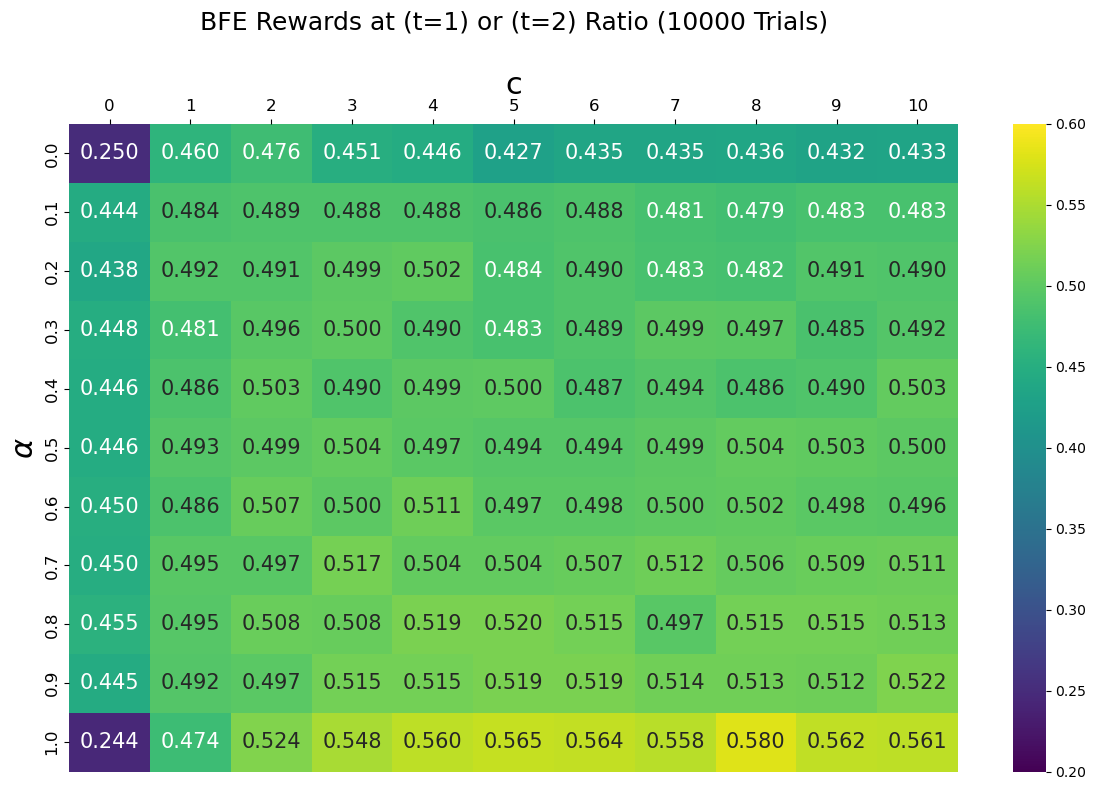

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

backup = np.load('simulation_bfe_backup.npz')
number_rewards = backup['rewards']
number_cues = backup['cues']
n_cue_and_reward = backup['cue_reward']
n_cue_and_no_reward = backup['cue_no_reward']
n_no_cue_and_reward = backup['no_cue_reward']
n_no_cue_and_no_reward = backup['no_cue_no_reward']

zeilen_namen = [rf"{i*0.1:.1f}" for i in range(z)]
spalten_namen = [f"{j}" for j in range(z)]

df_rewards = pd.DataFrame(number_rewards/10000, index=zeilen_namen, columns=spalten_namen)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(df_rewards,
                 annot=True,
                 cmap="viridis",
                 fmt=".3f",
                 annot_kws={'size': 15},
                 vmin=0.2,
                 vmax=0.6)

ax.xaxis.tick_top()
ax.tick_params(labelsize=12)

ax.xaxis.set_label_position('top')

plt.title("BFE Rewards at (t=1) or (t=2) Ratio (10000 Trials)", pad=30, fontsize=18) 
plt.ylabel(rf"$\alpha$", fontsize=22)
plt.xlabel("c", fontsize=22)

plt.tight_layout()
plt.show()

In [ ]:
# c = 0 : ~p = uniform
# c = 2 : ~p(reward) = 0.194
# c = 4 : ~p(reward) = 0.241
# c = 6 : ~p(reward) = 0.249
# c = 8 : ~p(reward) = 0.25
# c = 10 : ~p(reward) = 0.25